In [1]:
import sys
sys.path.append('..')  # pour importer portfolio_analytics depuis la racine
import numpy as np 
import pandas as pd
import portfolio_analytics as erk
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2
%matplotlib inline


In [2]:
n_scenarios = 500
rates, zc_prices = erk.cir(10, n_scenarios=n_scenarios, b=0.03, r_0=0.03, sigma=0.02)
prices_eq = erk.gbm(n_years=10, n_scenarios=n_scenarios, mu=0.07, sigma=0.15)

In [3]:
rets_eq = prices_eq.pct_change().dropna()
rets_zc = zc_prices.pct_change().dropna()
rets_7030b = erk.bt_mix(rets_eq, rets_zc, allocator=erk.fixedmix_allocator, w1=0.7)
pd.concat([
    erk.terminal_stats(rets_zc, name="ZC", floor=0.75),
    erk.terminal_stats(rets_eq, name="Eq", floor=0.75),
    erk.terminal_stats(rets_7030b, name="70/30", floor=0.75)],
    axis=1).round(2)

,ZC,Eq,70/30
mean,1.34,1.89,1.72
std,0.00,0.85,0.54
p_breach,NaN,0.03,0.01
e_short,NaN,0.12,0.04
p_reach,NaN,NaN,NaN
e_surplus,NaN,NaN,NaN


In [4]:
rets_floor75 = erk.bt_mix( rets_eq, rets_zc, allocator=erk.floor_allocator, floor=0.75, zc_prices = zc_prices[1:])
pd.concat([
    erk.terminal_stats(rets_zc, name="ZC", floor=0.75),
    erk.terminal_stats(rets_eq, name="Eq", floor=0.75),
    erk.terminal_stats(rets_7030b, name="70/30", floor=0.75),
    erk.terminal_stats(rets_floor75, name="Floor 0.75", floor=0.75)],
    axis=1).round(2)

,ZC,Eq,70/30,Floor 0.75
mean,1.34,1.89,1.72,1.87
std,0.00,0.85,0.54,0.86
p_breach,NaN,0.03,0.01,NaN
e_short,NaN,0.12,0.04,NaN
p_reach,NaN,NaN,NaN,NaN
e_surplus,NaN,NaN,NaN,NaN


In [5]:
rets_floor75m1 = erk.bt_mix( rets_eq, rets_zc, allocator=erk.floor_allocator, floor=0.75, zc_prices = zc_prices[1:], m=1)
rets_floor75m5 = erk.bt_mix( rets_eq, rets_zc, allocator=erk.floor_allocator, floor=0.75, zc_prices = zc_prices[1:], m=5)
pd.concat([
    erk.terminal_stats(rets_zc, name="ZC", floor=0.75),
    erk.terminal_stats(rets_eq, name="Eq", floor=0.75),
    erk.terminal_stats(rets_7030b, name="70/30", floor=0.75),
    erk.terminal_stats(rets_floor75, name="Floor 0.75", floor=0.75),
    erk.terminal_stats(rets_floor75m1, name="Floor 0.75 m1", floor=0.75),
    erk.terminal_stats(rets_floor75m5, name="Floor 0.75 m5", floor=0.75)],
    axis=1).round(2)

,ZC,Eq,70/30,Floor 0.75,Floor 0.75 m1,Floor 0.75 m5
mean,1.34,1.89,1.72,1.87,1.59,1.88
std,0.00,0.85,0.54,0.86,0.38,0.86
p_breach,NaN,0.03,0.01,NaN,NaN,NaN
e_short,NaN,0.12,0.04,NaN,NaN,NaN
p_reach,NaN,NaN,NaN,NaN,NaN,NaN
e_surplus,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
pd.concat([
    erk.terminal_stats(rets_zc, name="ZC", floor=0.75),
    erk.terminal_stats(rets_eq, name="Eq", floor=0.75),
    erk.terminal_stats(rets_7030b, name="70/30", floor=0.75),
    erk.terminal_stats(rets_floor75, name="Floor 0.75", floor=0.75),
    erk.terminal_stats(rets_floor75m1, name="Floor 0.75 m1", floor=0.75),
    erk.terminal_stats(rets_floor75m5, name="Floor 0.75", floor=0.75)],
    axis=1).round(2)

,ZC,Eq,70/30,Floor 0.75,Floor 0.75 m1,Floor 0.75
mean,1.34,1.89,1.72,1.87,1.59,1.88
std,0.00,0.85,0.54,0.86,0.38,0.86
p_breach,NaN,0.03,0.01,NaN,NaN,NaN
e_short,NaN,0.12,0.04,NaN,NaN,NaN
p_reach,NaN,NaN,NaN,NaN,NaN,NaN
e_surplus,NaN,NaN,NaN,NaN,NaN,NaN


###Riks budgestin with Drawdown Constraints

In [7]:
cashrate= 0.02
monthly_cashreturn = (1+cashrate)**(1/12)-1
rets_cash = pd.DataFrame(pd.DataFrame(data=monthly_cashreturn, index=rets_eq.index, columns=rets_eq.columns))
rets_maxdd25 = erk.bt_mix(rets_eq, rets_cash, allocator = erk.drawdown_allocator, maxdd=0.25)
tv_maxdd25 = erk.terminal_values(rets_maxdd25)
pd.concat([
    erk.terminal_stats(rets_zc, name="ZC", floor=0.75),
    erk.terminal_stats(rets_eq, name="Eq", floor=0.75),
    erk.terminal_stats(rets_7030b, name="70/30", floor=0.75),
    erk.terminal_stats(rets_floor75, name="Floor 0.75", floor=0.75),
    erk.terminal_stats(rets_floor75m1, name="Floor 0.75 m1", floor=0.75),
    erk.terminal_stats(rets_floor75m5, name="Floor 0.75", floor=0.75),
    erk.terminal_stats(rets_maxdd25, name="MaxDD 0.25", floor=0.75)],
    axis=1).round(3)

,ZC,Eq,70/30,Floor 0.75,Floor 0.75 m1,Floor 0.75,MaxDD 0.25
mean,1.343,1.895,1.716,1.871,1.589,1.882,1.589
std,0.000,0.854,0.536,0.861,0.377,0.862,0.476
p_breach,NaN,0.032,0.008,NaN,NaN,NaN,NaN
e_short,NaN,0.117,0.044,NaN,NaN,NaN,NaN
p_reach,NaN,NaN,NaN,NaN,NaN,NaN,NaN
e_surplus,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
erk.summary_stats(rets_maxdd25)["Max Drawdown"].min()

np.float64(-0.23018774402093933)

C:\Users\user\AppData\Local\Temp\ipykernel_22644\2643754770.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tv_eq, color="red", label="100% Equities", bins=100)
C:\Users\user\AppData\Local\Temp\ipykernel_22644\2643754770.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tv_7030b, color="o

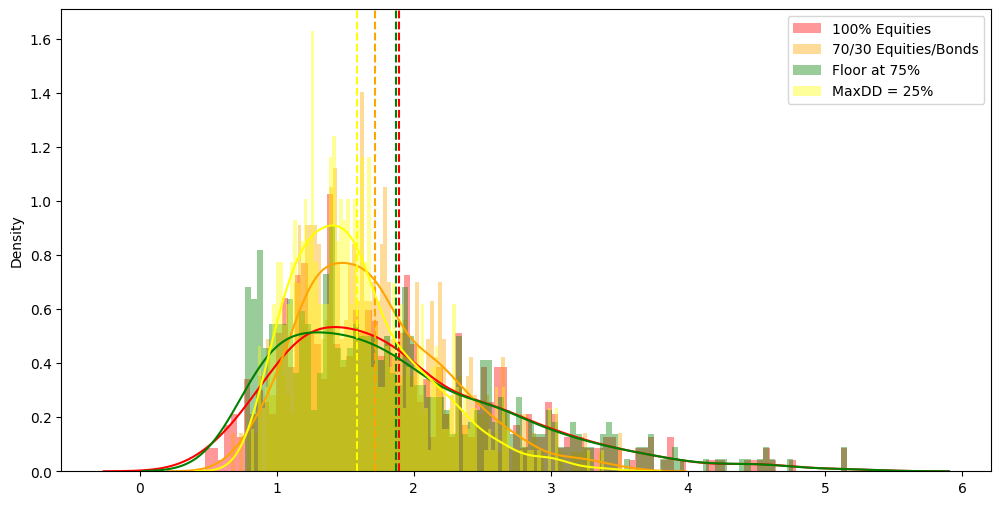

In [9]:
tv_eq = erk.terminal_values(rets_eq)
tv_zc = erk.terminal_values(rets_zc)
tv_7030b = erk.terminal_values(rets_7030b)
tv_floor75 = erk.terminal_values(rets_floor75)
tv_maxdd25 = erk.terminal_values(rets_maxdd25)
# Plot
plt.figure(figsize=(12, 6))
sns.distplot(tv_eq, color="red", label="100% Equities", bins=100)
plt.axvline(tv_eq.mean(), ls="--", color="red")
sns.distplot(tv_7030b, color="orange", label="70/30 Equities/Bonds", bins=100)
plt.axvline(tv_7030b.mean(), ls="--", color="orange")
sns.distplot(tv_floor75, color="green", label="Floor at 75%", bins=100)
plt.axvline(tv_floor75.mean(), ls="--", color="green")
sns.distplot(tv_maxdd25, color="yellow", label="MaxDD = 25%", bins=100)
plt.axvline(tv_maxdd25.mean(), ls="--", color="yellow")
plt.legend();

In [10]:
rets_tmis = erk.get_total_market_index_returns()['1990':]
dd_tmi = erk.drawdown(rets_tmis)
ax = dd_tmi["Wealth"].plot(figsize=(12, 6), color="red", ls='--')
dd_tmi["Previous Peak"].plot(ax=ax, color="black", ls='--')


NameError: name 'get_ind_nfirms' is not defined